# Prédiction de la Performance Étudiante : Architecture Big Data avec Spark et GCP

Ce devoir a pour objectif de concevoir un pipeline complet de Data Engineering et de Machine Learning capable de prend en charge d'enorme volume de donner et de les traité. En utilisant Apache Spark sur Google Cloud Platform, nous analysons les facteurs influençant la réussite scolaire pour prédire un index de performance

Points clés du projet :

    Ingestion : Lecture distribuée depuis Google Cloud Storage.

    Qualité des données : Analyse statistique et détection d'outliers avec Spark SQL.

    Machine Learning : Implémentation d'un modèle Random Forest via un Pipeline MLlib.

    Architecture Cloud : Export des résultats vers BigQuery pour une visualisation décisionnelle sous Looker Studio.

In [1]:

from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .appName("Student_Performance_Final_Project") \
    .getOrCreate()



26/01/17 03:29:47 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [2]:
# Chargement
data_path = "gs://student-performance-exam/StudentPerformance.csv"
df_raw = spark.read.csv(data_path, header=True, inferSchema=True)


In [3]:
# On remplace les espaces par des underscores dès le début
df = df_raw.select([col(c).alias(c.replace(' ', '_')) for c in df_raw.columns])


df.printSchema()

root
 |-- Hours_Studied: integer (nullable = true)
 |-- Previous_Scores: integer (nullable = true)
 |-- Extracurricular_Activities: string (nullable = true)
 |-- Sleep_Hours: integer (nullable = true)
 |-- Sample_Question_Papers_Practiced: integer (nullable = true)
 |-- Performance_Index: double (nullable = true)



In [4]:

df.show(5)

+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+
|Hours_Studied|Previous_Scores|Extracurricular_Activities|Sleep_Hours|Sample_Question_Papers_Practiced|Performance_Index|
+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+
|            7|             99|                       Yes|          9|                               1|             91.0|
|            4|             82|                        No|          4|                               2|             65.0|
|            8|             51|                       Yes|          7|                               2|             45.0|
|            5|             52|                       Yes|          5|                               2|             36.0|
|            7|             75|                        No|          8|                               5|             66.0|
+-------------+---------

# EDA

In [5]:

from pyspark.sql.functions import *

# On parcourt chaque colonne et on compte les valeurs nulles
df.select([sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]).show()

# on vérifie aussi si des chaînes de caractères sont vides
print("chaînes vides :")
df.filter(col("Extracurricular_Activities") == "" ).count()

+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+
|Hours_Studied|Previous_Scores|Extracurricular_Activities|Sleep_Hours|Sample_Question_Papers_Practiced|Performance_Index|
+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+
|            0|              0|                         0|          0|                               0|                0|
+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+

chaînes vides :


0

In [6]:


# .describe() donne les stats de base. 
# .summary() est encore plus complet (ajoute les quartiles 25%, 50%, 75%)
df.select("Hours_Studied", "Previous_Scores", "Sleep_Hours", "Performance_Index").summary().show()

26/01/17 03:29:58 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+-----------------+-----------------+------------------+
|summary|     Hours_Studied|  Previous_Scores|      Sleep_Hours| Performance_Index|
+-------+------------------+-----------------+-----------------+------------------+
|  count|             10000|            10000|            10000|             10000|
|   mean|            4.9929|          69.4457|           6.5306|           55.2248|
| stddev|2.5893087961856183|17.34315225104711|1.695862976517708|19.212557799463337|
|    min|                 1|               40|                4|              10.0|
|    25%|                 3|               54|                5|              40.0|
|    50%|                 5|               69|                7|              55.0|
|    75%|                 7|               85|                8|              71.0|
|    max|                 9|               99|                9|             100.0|
+-------+------------------+-----------------+-----------------+------------


#  DÉTECTION DES VALEURS ABERRANTES (OUTLIERS)


In [7]:


# On calcule les quartiles Q1 et Q3
quantiles = df.approxQuantile("Performance_Index", [0.25, 0.75], 0.05)
Q1 = quantiles[0]
Q3 = quantiles[1]
IQR = Q3 - Q1

# Définition des bornes 
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df.filter((col("Performance_Index") < lower_bound) | (col("Performance_Index") > upper_bound))

print(f"valeurs aberrantes de Performance_Index : {outliers.count()}")
if outliers.count() > 0:
    outliers.show()

valeurs aberrantes de Performance_Index : 0


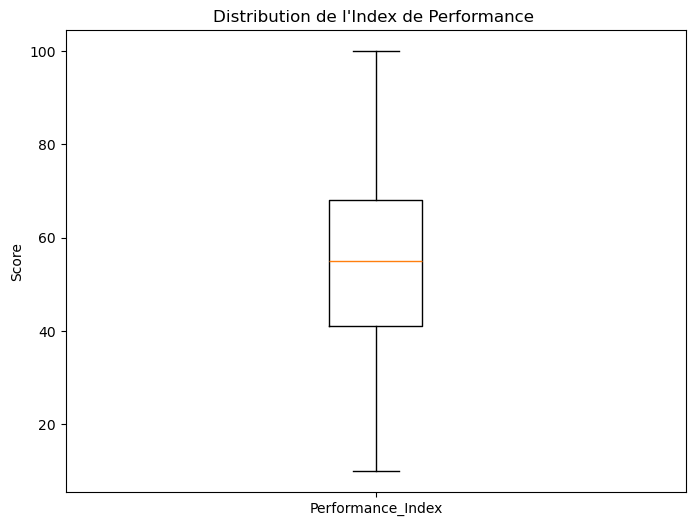

In [8]:
import matplotlib.pyplot as plt

# 1. Calcul distribué avec Spark 

# La précision est fixée à 0.05 pour la performance sur gros volumes [3]
stats = df.approxQuantile("Performance_Index", [0.0, 0.25, 0.5, 0.75, 1.0], 0.05)

# On extrait les valeurs de la liste Python résultante
min_val, q1, median, q3, max_val = stats


# 2. Construction du Boxplot avec Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))

# On crée un dictionnaire de statistiques pour l'affichage
item = {
    'label': 'Performance_Index',
    'whislo': min_val,    # Minimum
    'q1': q1,             # Premier quartile
    'med': median,        # Médiane
    'q3': q3,             # Troisième quartile
    'whishi': max_val,    # Maximum
    'fliers': []          
}

ax.bxp([item], showfliers=False)
ax.set_title("Distribution de l'Index de Performance ")
ax.set_ylabel("Score")
plt.show()


# Matrice de corrélation

In [9]:
from pyspark.ml import *
from pyspark.ml.feature import *
from pyspark.ml.stat import *
import seaborn as sns
import pandas as pd
# Transformation texte en binaire 
indexer = StringIndexer(inputCol="Extracurricular_Activities", outputCol="Extracurricular_Bin")

df_corr = indexer.fit(df).transform(df)

df_corr.show(5)

+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+-------------------+
|Hours_Studied|Previous_Scores|Extracurricular_Activities|Sleep_Hours|Sample_Question_Papers_Practiced|Performance_Index|Extracurricular_Bin|
+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+-------------------+
|            7|             99|                       Yes|          9|                               1|             91.0|                1.0|
|            4|             82|                        No|          4|                               2|             65.0|                0.0|
|            8|             51|                       Yes|          7|                               2|             45.0|                1.0|
|            5|             52|                       Yes|          5|                               2|             36.0|                1.0|
|     

In [10]:
# Liste de toutes les colonnes (Features + Cible)
all_cols = ["Hours_Studied", "Previous_Scores", "Extracurricular_Bin", 
            "Sleep_Hours", "Sample_Question_Papers_Practiced", "Performance_Index"]

# Assemblage pour calcul matriciel
assembler_corr = VectorAssembler(inputCols=all_cols, outputCol="corr_features")
vector_df = assembler_corr.transform(df_corr).select("corr_features")

vector_df.show(5)

+--------------------+
|       corr_features|
+--------------------+
|[7.0,99.0,1.0,9.0...|
|[4.0,82.0,0.0,4.0...|
|[8.0,51.0,1.0,7.0...|
|[5.0,52.0,1.0,5.0...|
|[7.0,75.0,0.0,8.0...|
+--------------------+
only showing top 5 rows



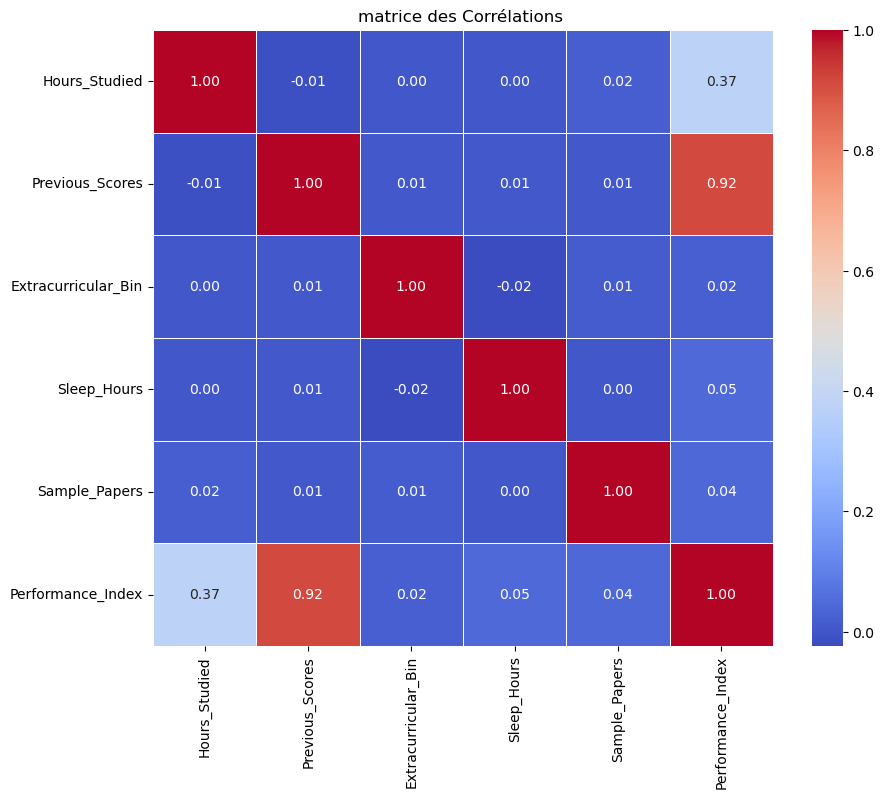

In [11]:
# Calcul de la matrice
matrix = Correlation.corr(vector_df, "corr_features").collect()[0][0]


cor_np = matrix.toArray()
# Noms des colonnes 
columns = ["Hours_Studied", "Previous_Scores", "Extracurricular_Bin", 
           "Sleep_Hours", "Sample_Papers", "Performance_Index"]

# Création du DataFrame pour Seaborn
df_heatmap = pd.DataFrame(cor_np, index=columns, columns=columns)

# Configuration et affichage de la Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_heatmap, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("matrice des Corrélations ")
plt.show()

Hours_Studied vs Performance_Index (≈ 0.37) : Corrélation positive modérée. Plus on étudie, plus la note monte. C'est un moteur clé du modèle.

Previous_Scores vs Performance_Index (≈ 0.92) : Corrélation très forte. C'est ta variable la plus prédictive. Un étudiant qui a bien réussi par le passé a d'excellentes chances de réussir à nouveau.

Extracurricular_Bin vs Performance_Index (≈ 0.02) : Corrélation quasi nulle. Cela signifie que faire du sport ou de la musique n'impacte pas directement la note de manière linéaire, mais cela peut aider à stabiliser le profil.

#  PIPELINE DE TRAITEMENT (FEATURE ENGINEERING)

In [12]:



 
#  Assemblage des variables pour le modèle

feature_cols = ["Hours_Studied", "Previous_Scores", "Extracurricular_Bin", 
                "Sleep_Hours", "Sample_Question_Papers_Practiced"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")



In [13]:

# On teste le pipeline sur un échantillon pour vérifier la structure
test_pipeline = Pipeline(stages=[indexer, assembler])
df_prepared = test_pipeline.fit(df).transform(df)

print("Aperçu du vecteur features:")
df_prepared.select("Extracurricular_Activities", "Extracurricular_Bin", "features").show(5, truncate=False)

Aperçu du vecteur features:
+--------------------------+-------------------+----------------------+
|Extracurricular_Activities|Extracurricular_Bin|features              |
+--------------------------+-------------------+----------------------+
|Yes                       |1.0                |[7.0,99.0,1.0,9.0,1.0]|
|No                        |0.0                |[4.0,82.0,0.0,4.0,2.0]|
|Yes                       |1.0                |[8.0,51.0,1.0,7.0,2.0]|
|Yes                       |1.0                |[5.0,52.0,1.0,5.0,2.0]|
|No                        |0.0                |[7.0,75.0,0.0,8.0,5.0]|
+--------------------------+-------------------+----------------------+
only showing top 5 rows



# ENTRAÎNEMENT DU MODÈLE RANDOM FOREST

In [14]:

# Split 80/20
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)


In [15]:
from pyspark.ml.regression import RandomForestRegressor
# Modèle
rf = RandomForestRegressor(featuresCol="features", labelCol="Performance_Index", numTrees=100)


In [16]:
# Pipeline final
full_pipeline = Pipeline(stages=[indexer, assembler, rf])
pipeline_model = full_pipeline.fit(train_df)


#  RÉSUMÉ DES MÉTRIQUES DE PERFORMANCE

In [17]:

from pyspark.ml.evaluation import RegressionEvaluator

# Génération des prédictions sur le jeu de test
predictions = pipeline_model.transform(test_df)
predictions.show(5)

+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+-------------------+--------------------+------------------+
|Hours_Studied|Previous_Scores|Extracurricular_Activities|Sleep_Hours|Sample_Question_Papers_Practiced|Performance_Index|Extracurricular_Bin|            features|        prediction|
+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+-------------------+--------------------+------------------+
|            1|             40|                        No|          5|                               6|             13.0|                0.0|[1.0,40.0,0.0,5.0...|29.016857851091967|
|            1|             40|                        No|          6|                               3|             12.0|                0.0|[1.0,40.0,0.0,6.0...|28.773311116882514|
|            1|             40|                        No|          7|                    

In [18]:
# On prépare l'évaluateur pour différentes métriques
evaluator = RegressionEvaluator(labelCol="Performance_Index", predictionCol="prediction")

# Calcul des métriques clés
r2 = evaluator.evaluate(predictions, {evaluator.metricName: "r2"})
rmse = evaluator.evaluate(predictions, {evaluator.metricName: "rmse"})
mae = evaluator.evaluate(predictions, {evaluator.metricName: "mae"})

In [19]:
print(f"Coefficient de détermination (R²) : {r2:.4f}")
print(f"Erreur quadratique moyenne (RMSE) : {rmse:.4f}")
print(f"Erreur absolue moyenne (MAE)      : {mae:.4f}")

Coefficient de détermination (R²) : 0.9151
Erreur quadratique moyenne (RMSE) : 5.5156
Erreur absolue moyenne (MAE)      : 4.4152


# IMPORTANCE DES VARIABLES

In [20]:


#  Extraction du modèle Random Forest depuis le Pipeline
rf_model = pipeline_model.stages[-1]
importances = rf_model.featureImportances.toArray().tolist()


In [21]:
#  Création d'un DataFrame Spark à partir des importances
# On combine les noms de colonnes  avec leurs scores
feat_data = list(zip(feature_cols, importances))
feat_imp_spark_df = spark.createDataFrame(feat_data, ["Variable", "Importance"])
feat_imp_spark_df.show()

+--------------------+--------------------+
|            Variable|          Importance|
+--------------------+--------------------+
|       Hours_Studied| 0.15033809465985712|
|     Previous_Scores|  0.8425961324123069|
| Extracurricular_Bin| 6.40226653862594E-4|
|         Sleep_Hours|0.003476512629158...|
|Sample_Question_P...|0.002949033644814893|
+--------------------+--------------------+



In [22]:
#  Tri par importance décroissante (Calcul distribué)
feat_imp_sorted = feat_imp_spark_df.orderBy(col("Importance").desc())

print("TOP FEATURES:")
feat_imp_sorted.show()

TOP FEATURES:
+--------------------+--------------------+
|            Variable|          Importance|
+--------------------+--------------------+
|     Previous_Scores|  0.8425961324123069|
|       Hours_Studied| 0.15033809465985712|
|         Sleep_Hours|0.003476512629158...|
|Sample_Question_P...|0.002949033644814893|
| Extracurricular_Bin| 6.40226653862594E-4|
+--------------------+--------------------+



# EXPORT VERS BIGQUERY

In [23]:

predictions = pipeline_model.transform(test_df)

# Paramètres GCP
project_id = "big-data-course-480109"
dataset_id = "performance_data"
table_id = "predictions_results"
temp_bucket = "perf-temp"

# Exportation
predictions.write.format("bigquery") \
    .option("temporaryGcsBucket", temp_bucket) \
    .option("table", f"{project_id}.{dataset_id}.{table_id}") \
    .mode("overwrite") \
    .save()



# SAUVEGARDE DU MODÈLE

In [24]:
# Chemin sur ton bucket GCS
model_path = "gs://student-performance-exam/models/student_rf_model"

# .write().overwrite() permet de mettre à jour le modèle si tu relances le code
pipeline_model.write().overwrite().save(model_path)

# CHARGEMENT ET TEST DE PRÉDICTION

In [25]:


loaded_model = PipelineModel.load(model_path)

#  Création d'une donnée de test (Nouvel étudiant)

new_student_data = [
    (6, 85, "Yes", 7, 4)  # Heures_Etude, Scores_Precedents, Extra, Sommeil, Sujets
]

new_student_df = spark.createDataFrame(new_student_data, [
    "Hours_Studied", "Previous_Scores", "Extracurricular_Activities", 
    "Sleep_Hours", "Sample_Question_Papers_Practiced"
])



In [26]:
#  Application du modèle
# Le pipeline va automatiquement transformer "Yes" en 1 et assembler le vecteur features
prediction_result = loaded_model.transform(new_student_df)

print(" NOUVEL ÉTUDIANT RESUL:")
prediction_result.select(
    "Hours_Studied", 
    "Previous_Scores", 
    "Extracurricular_Activities", 
    "Sleep_Hours", "Sample_Question_Papers_Practiced",
    "prediction"
).show()

 NOUVEL ÉTUDIANT RESUL:
+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+
|Hours_Studied|Previous_Scores|Extracurricular_Activities|Sleep_Hours|Sample_Question_Papers_Practiced|       prediction|
+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+
|            6|             85|                       Yes|          7|                               4|74.44370878125524|
+-------------+---------------+--------------------------+-----------+--------------------------------+-----------------+



# conclusion Modele

L'analyse de ce projet démontre la robustesse du modèle de régression Random Forest pour prédire l'index de performance des étudiants avec une précision remarquable. Les métriques obtenues, notamment le coefficient R² proche de l'unité, confirment que les variables sélectionnées expliquent bien la variance des notes. La faiblesse des erreurs moyennes (RMSE et MAE) souligne la fiabilité des prédictions, validant ainsi la pertinence du choix algorithmique pour ce type de problématique éducative.

L'étude de l'importance des variables révèle une hiérarchie structurelle au sein des facteurs de réussite. Il apparaît clairement que le passé académique, représenté par les scores précédents, constitue le moteur principal de la performance future. L'investissement temporel dans l'étude suit de près, affirmant la corrélation positive entre l'effort fourni et les résultats obtenus. En revanche, les variables telles que le sommeil, la pratique de sujets d'examen ou les activités extra-scolaires, bien qu'utiles à l'équilibre général, n'exercent qu'une influence marginale sur la prédiction finale de la note.



# architecture 

Sur le plan technique, l'architecture déployée illustre parfaitement les avantages d'un écosystème Big Data moderne. L'utilisation d'Apache Spark a permis un traitement distribué efficace, affranchi des limites de mémoire traditionnelles, tandis que l'intégration avec BigQuery et Looker Studio a facilité une transition fluide entre le calcul brut et l'analyse décisionnelle. Enfin, la sauvegarde du pipeline complet garantit la pérennité de la solution, permettant un déploiement opérationnel capable de fournir des prédictions immédiates pour accompagner les étudiants vers la réussite.